# 2016 US Electoral Integrity Perception

This data comes from the Electoral Integrity Project based at the universities of Sydney and Harvard. The study was conducted by Pippa Norris, Alessandro Nai and Max Grömping. Based on a survey collecting the views of US-based political scientists. 

This research provides independent and reliable evidence to assess if the 2016 presidential election met international standards of electoral integrity. The survey asks respondents to evaluate how the presidential election on 8 November 2016 was conducted in each of the 50 US states plus the District of Columbia.

## (1) Problem Statement

This project analyses expert survey responses on perceptions of electoral integrity for the 2016 US presidential election. Using a dataset of 726 expert responses and 85 features covering voting processes, media coverage, campaign finances and electoral administraion, the project addresses three main questions:

1. What factors most influence experts' overall perceptions of electoral integrity? (Regression)

2. Can which candidate an expert supported be predicted based on their integrity assessments? (Classification)

3. Do distinct expert 'profiles' emerge from patterns in their responses? (Clustering)

## (2) Data Collection

- Dataset source: Norris, P., Nai, A. and Grömping, M. (2016) Perceptions of Electoral Integrity - US 2016 (PEI_US_1.0) [Dataset]. Harvard Dataverse. Available at: https://doi.org/10.7910/DVN/YXUV3W (Accessed: 20 March 2026).
- The dataset consists of 85 columns and 726 rows.

### 2.1: Import data and packages

In [1]:
# Import packages

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Import csv as a pandas dataframe

df = pd.read_csv('data/survey.csv')

In [5]:
# Show top 5 records

df.head()

,Election Year,Expert ID,State,Sex,Age Range,Politician,Candidate,Activist,Monitor,Election Official,...,Electoral Authorities Index,Election Rigged,Deadlines Restrictive,Voters Waited,Voters Intimidated,Multiple Ballots Cast,Machines Accurate,Records Secure,Votes Counted Quickly,Outcome Reflected Popular Will
0,2016,1,Alabama,Male,50-59,NaN,NaN,NaN,NaN,NaN,...,68.75,Disagree,Disagree,Strongly Agree,Don't Know,Don't Know,Agree,Don't Know,Agree,Disagree
1,2016,2,Alabama,Male,60-69,NaN,NaN,NaN,NaN,NaN,...,56.25,Strongly Disagree,Agree,Neither Agree Nor Disagree,Neither Agree Nor Disagree,Strongly Disagree,Agree,Don't Know,Agree,Agree
2,2016,3,Alabama,Male,60-69,NaN,NaN,NaN,NaN,NaN,...,62.50,Disagree,Disagree,Agree,Disagree,Don't Know,Neither Agree Nor Disagree,Neither Agree Nor Disagree,Strongly Agree,Neither Agree Nor Disagree
3,2016,4,Alabama,Male,50-59,NaN,NaN,NaN,NaN,NaN,...,75.00,Disagree,Strongly Agree,Strongly Agree,Don't Know,Disagree,Agree,Agree,Agree,Strongly Disagree
4,2016,5,Alabama,Male,40-49,NaN,NaN,NaN,NaN,NaN,...,74.06,Disagree,Disagree,Disagree,Disagree,Strongly Disagree,Agree,Agree,Strongly Agree,Strongly Agree


In [6]:
# Check dataset shape

df.shape

(726, 85)

### 2.2: Dataset information

DEMOGRAPHICS AND IDENTITY:

- Election Year:	Year of the election (all 2016)
- Expert ID:	Unique identifier for each respondent
- State:	US state the expert is reporting on
- Sex:	Gender of the respondent
- Age Range:	Age bracket (e.g., 50-59, 60-69)
- Political Scale:	Self-reported left-right political orientation (numeric scale)
- Candidate Supported:	Which 2016 candidate the expert supported (Clinton, Trump, Stein, etc.)

ROLE INDICATORS (BINARY):

- Politician:	Respondent is/was an elected official
- Candidate:	Respondent has stood as a candidate
- Activist: 	Respondent is a political activist
- Monitor: 	Respondent is an election monitor/observer
- Election Official:	Respondent is/was an election administrator
- Voter:	Respondent voted in the election
- Citizen:	Respondent is a US citizen

OVERALL INTEGRITY SCORES (NUMERIC):

- Perceptions of Electoral Integrity Index: 	Composite PEI score (regression target)
- State Electoral Integrity:	Rating of electoral integrity at the state level (1-10 scale)
- National Electoral Integrity: 	Rating of electoral integrity at the national level (1-10 scale)

ELECTORAL LAWS (LIKERT AND INDEX):

- Laws Discriminated:	Electoral laws discriminated against some parties/candidates
- Laws Favored Incumbent:	Electoral laws favored the governing party
- Laws Restricted Citizen Rights:	Electoral laws restricted citizens' rights
- Electoral Laws Index: 	Composite score for the above three items

ELECTORAL PROCECURES (LIKERT AND INDEX):

- Election Managed Well:	Elections were well managed
- Voting Information Available: 	Information about voting procedures was widely available
- Election Officials Fair: 	Election officials were fair
- Election Followed Law: 	Elections were conducted in accordance with the law
- Election Procedures Index:	Composite score for the above four items

DISTRICT BOUNDARIES (LIKERT AND INDEX):

- Boundaries Discriminated: 	Boundaries discriminated against some parties/candidates
- Boundaries Favored Incumbent: 	Boundaries favored the governing party
- Boundaries Impartial: 	Boundaries were drawn impartially
- Voting District Boundaries Index: 	Composite score for the above three items

VOTER REGISTRATION (LIKERT AND INDEX):

- Citizens Not Found in Register:	Some citizens were not found in the registration register
- Register Inaccurate: 	The electoral register was inaccurate
- Ineligible Voters Registered: 	Ineligible voters were registered
- Voter Registration Index: 	Composite score for the above three items

PARTY/CANDIDATE REGISTRATION (LIKERT AND INDEX):

- Opposition Prevented: 	Opposition candidates were prevented from running
- Women Provided Opportunity: 	Women had equal opportunity to run for office
- Leaders Selected Candidates: 	Party leaders selected candidates rather than members
- Campaign Rallies Restricted: 	Campaign rallies and events were restricted
- Party/Candidate Registration Index:	Composite score for the above four items

MEDIA COVERAGE (LIKERT AND INDEX):

- Newspapers Balanced:  	Newspapers provided balanced election news
- Television Favored Incumbent: 	TV news favored the governing party
- Media Access Fair:	Parties/candidates had fair access to media
- Media Coverage Fair: 	Media coverage of the election was fair overall
- Social Media Exposed Fraud: 	Social media was used to expose electoral fraud
- Media Coverage Index: 	Composite score for the above five items

CAMPAGIN FINANCE (LIKERT AND INDEX):

- Subsidy Access Fair: 	Parties/candidates had equitable access to public subsidies
- Donation Access Fair: 	Parties/candidates had equitable access to political donations
- Campaign Accounts Transparent: 	Campaign accounts were transparent
- Elections Bought by Rich: 	Rich people were able to buy elections
- Resources Improperly Used:	State resources were used improperly for campaigning
- Campaign Finance Index: 	Composite score for the above five items

VOTING PROCESS (LIKERT AND INDEX):

- Voters Threatened with Violence: 	Voters were threatened with violence at the polls
- Fradulent Votes Cast: 	Fraudulent votes were cast
- Voting Process Easy: 	The process of voting was easy
- Choice of Candidates: 	Voters had a genuine choice of candidates
- Postal Ballots Available: 	Postal ballots were available
- Disabled Provided Access: 	Disabled people could access polling stations
- Expatriates Able to Vote: 	Expatriates could vote
- Internet Ballots Available: 	Internet voting was available
- Voting Process Index: 	Composite score for the above eight items

VOTE COUNT (LIKERT AND INDEX):

- Ballot Boxes Secure: 	Ballot boxes were secure
- Results Announced Without Delay: 	Results were announced without unreasonable delay
- Vote Count Fair: 	Votes were counted fairly
- International Monitors Restricted:	International election monitors were restricted
- Domestic Monitors Restricted: 	Domestic election monitors were restricted
- Vote Count Index: 	Composite score for the above five items

ELECTION RESULTS (LIKERT AND INDEX):

- Results Challenged: 	Losing candidates challenged the results
- Protests Peaceful: 	Post-election protests were peaceful
- Protests Violent: 	Post-election protests led to violence
- Dispute Resolved in Courts: 	Any disputes were resolved through legal channels
- Election Results Index:	Composite score for the above four items

ELECTORAL AUTHORITIES (LIKERT AND INDEX):

- Authorities Impartial: 	Electoral authorities were impartial
- Information Distributed: 	Electoral authorities distributed information to citizens
- Authorities Scrutinized: 	Electoral authorities were subject to public scrutiny
- Authorities Performed Well: 	Electoral authorities performed well
- Electoral Authorities Index: 	Composite score for the above four items

ADDITIONAL INTEGRITY ITEMS (LIKERT AND NO COMPOSITE INDEX):

- Election Rigged: 	The election was rigged
- Deadlines Restrictive: 	Voter registration deadlines were too restrictive
- Voters Waited: 	Some voters had to wait excessively long to vote
- Voters Intimidated: 	Voters were intimidated at polling stations
- Multiple Ballots Cast: 	Multiple ballots were cast by single individuals
- Machines Accurate: 	Voting machines were accurate
- Records Secure:	Electoral records were secure
- Votes Counted Quickly:	Votes were counted in a timely manner
- Outcome Reflected Popular Will:	The election outcome reflected the will of the people

NOTES:

- Lots of composute features so beware of multicollinearity.
- Look into Ridge/Lasso regression.
- Beware of target leakage.
- Ordinal encoded Likert data treated as numeric is technically non-linear.
- Regularisation likely to be necessary.
- This doesn't lend itself to a live prediction system. Is more of a demonstration of end-to-end engineering capabilities delivered via an interesting subject.

## (3) Data Checks

Will include:
- Check missing values
- Check duplicates
- Check data type
- Check unique values for each column
- Check statistics of dataset
- Check categories present in categorical columns

### 3.1: Check missing values

In [ ]:
# Missing value check
df.isna().sum()

Election Year                     0
Expert ID                         0
State                             0
Sex                               0
Age Range                         0
                                 ..
Multiple Ballots Cast             2
Machines Accurate                 2
Records Secure                    3
Votes Counted Quickly             0
Outcome Reflected Popular Will    1
Length: 85, dtype: int64

In [ ]:
# Missing values in descending order
df.isna().sum().sort_values(ascending=False)

Candidate                            723
Monitor                              722
Politician                           720
Activist                             717
Election Official                    715
                                    ... 
Election Followed Law                  0
Results Announced Without Delay        0
International Monitors Restricted      0
Voters Waited                          0
Votes Counted Quickly                  0
Length: 85, dtype: int64

In [9]:
# Percentage of missing values
(df.isna().sum() / len(df) * 100).sort_values(ascending=False)

Candidate                            99.586777
Monitor                              99.449036
Politician                           99.173554
Activist                             98.760331
Election Official                    98.484848
                                       ...    
Election Followed Law                 0.000000
Results Announced Without Delay       0.000000
International Monitors Restricted     0.000000
Voters Waited                         0.000000
Votes Counted Quickly                 0.000000
Length: 85, dtype: float64

Some missing values in the dataset. These will have to be dealt with.

Likely different tyes of missingness. Some are binary indicators where 1 = expert has the role and blank mean sthey don't. Impute 0 here. 

In [ ]:
# Impute zeros into missing values for binary indicators
role_cols = ['Politician', 'Candidate', 'Activist', 'Monitor', 'Election Official', 'Voter', 'Citizen']
df[role_cols] = df[role_cols].fillna(0)

In [12]:
df.isna().sum().sort_values(ascending=False)

Candidate Supported                         108
Electoral Laws Index                         30
Perceptions of Electoral Integrity Index     11
Vote Count Index                             10
Voter Registration Index                      9
                                           ... 
Election Followed Law                         0
Results Announced Without Delay               0
International Monitors Restricted             0
Voters Waited                                 0
Votes Counted Quickly                         0
Length: 85, dtype: int64

Candidate supported is the classification target. Can't impute this as it would be fabricating labels. Drop these rows ONLY when training classifier. Keep for regression and clustering.

The rest seem to be index columns. Likely that they answered 'don't know' or 'N/A' to all underlying questions that make up these composites so an index couldn't eb calculated. It's at most 30 rows so can just drop, use median imputation or let model handle it.

### 3.2: Check duplicates

In [13]:
# Check duplicates
df.duplicated().sum()

np.int64(0)

No duplicates

### 3.3: Check data types

In [14]:
# Check Null and dtypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 726 entries, 0 to 725
Data columns (total 85 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Election Year                             726 non-null    int64  
 1   Expert ID                                 726 non-null    int64  
 2   State                                     726 non-null    str    
 3   Sex                                       726 non-null    str    
 4   Age Range                                 726 non-null    str    
 5   Politician                                726 non-null    float64
 6   Candidate                                 726 non-null    float64
 7   Activist                                  726 non-null    float64
 8   Monitor                                   726 non-null    float64
 9   Election Official                         726 non-null    float64
 10  Voter                                     726 non

All non-null, mostly string, most numbers are floats with two instances of integer (Election Year, Expert ID) and one instance of object (Citizen)

### 3.4: Check unique values

In [15]:
df.nunique()

Election Year                       1
Expert ID                         726
State                              51
Sex                                 2
Age Range                           7
                                 ... 
Multiple Ballots Cast               7
Machines Accurate                   7
Records Secure                      7
Votes Counted Quickly               7
Outcome Reflected Popular Will      7
Length: 85, dtype: int64

In [16]:
df.nunique().sort_values(ascending=False)

Expert ID                                   726
Perceptions of Electoral Integrity Index    561
Voting Process Index                        204
Campaign Finance Index                      199
Media Coverage Index                        170
                                           ... 
Activist                                      2
Sex                                           2
Election Official                             2
Candidate                                     2
Election Year                                 1
Length: 85, dtype: int64

Most of the unique values are indexes

### 3.5: Check dataset statistics

In [17]:
# Check dataset statistics
df.describe()

,Election Year,Expert ID,Politician,Candidate,Activist,Monitor,Election Official,Voter,Political Scale,Perceptions of Electoral Integrity Index,...,Election Procedures Index,Voting District Boundaries Index,Voter Registration Index,Party/Candidate Registration Index,Media Coverage Index,Campaign Finance Index,Voting Process Index,Vote Count Index,Election Results Index,Electoral Authorities Index
count,726.0,726.000000,726.000000,726.000000,726.000000,726.000000,726.000000,726.000000,718.000000,715.000000,...,724.000000,723.000000,717.000000,722.000000,722.000000,718.000000,719.000000,716.000000,721.000000,721.000000
mean,2016.0,363.500000,0.008264,0.004132,0.012397,0.005510,0.015152,0.877410,3.362117,62.501692,...,78.649959,29.090636,55.884393,73.227839,52.045720,51.169624,68.157079,78.296047,61.800069,73.380166
std,0.0,209.722436,0.090595,0.064194,0.110724,0.074073,0.122240,0.328192,1.538828,10.998161,...,18.373292,24.986580,16.203786,17.609712,17.140193,17.937146,11.599253,12.420314,12.122071,18.830607
min,2016.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,15.310000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,25.000000,15.000000,22.500000,0.000000
25%,2016.0,182.250000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000,55.205000,...,68.750000,8.330000,47.500000,64.000000,40.000000,39.812500,61.800000,72.000000,56.250000,62.500000
50%,2016.0,363.500000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000,62.240000,...,75.000000,25.000000,55.830000,75.000000,54.500000,51.125000,68.750000,76.250000,62.500000,75.000000
75%,2016.0,544.750000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.000000,70.540000,...,93.750000,41.670000,64.170000,85.000000,65.000000,65.000000,76.090000,88.000000,68.750000,82.500000
max,2016.0,726.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10.000000,89.900000,...,100.000000,100.000000,100.000000,100.000000,95.000000,100.000000,96.880000,100.000000,100.000000,100.000000


Interesting observations at a glance:

- Political scale skews left. Mean is 3.36 with standard deviation of 1.53. Median is 3. Classification model will be working with an unbalanced sample and clustering will probably discover sub-groups within the left rather than a clean left/right split.

- Voting district boundaries are viewed very poorly. Mean of 29.1, standard deviation of 24.9. Median of 25. Very low rating for electoral integrity. Experts view gerrymandering as a serious problem (even 75th percentile is only 41.7). Could be a strong differentaiting feature across models.

- PEI is reasonably distributed. Mean 62.5, standard deviation 11, range 15-90. No severe skew. Decent regression target.

- Lots of nearly empty role columns. Even after filling NaN with 0, very few people are politicans, candidates, activists or offcials. Over 87% are voters. Not much variance, so might want to drop or combine. 

- Campaign finance is polarised. Mean of 51 with standard deviation of 18. 25th percentile to 75th shows big spread. Experts disagreed a lot about whether campaign finance was fair so could be a good feature to cluster on.

- Media coverage is low. Median of 54.5. Lukewarm at best about media fairness. Experts rate things like prodedures of voting highly but things around it (boundaries, media, finances) poorly. 

## (4) EDA (Regression Focused)

- Target variable analysis
- Correlation analysis
- PEI vs demographic features
- PEI vs index columns
- Categorical response distributions
- Feature set decision

### 4.1: Target variable analysis

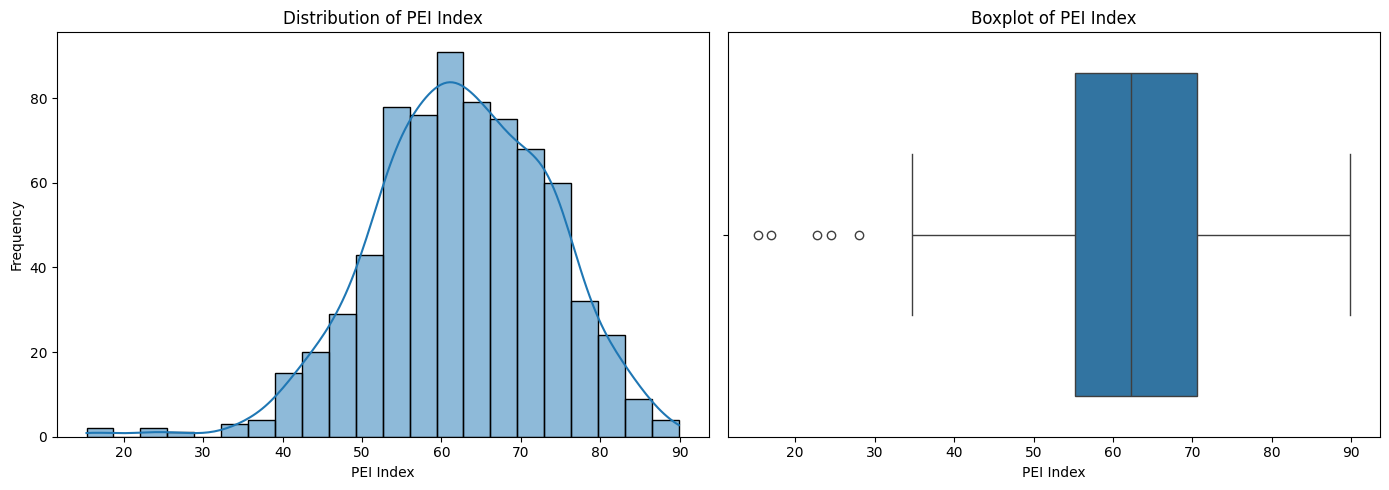

Skewness: -0.364


In [18]:
# Histogram/KDE/boxplot of PEI index
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
sns.histplot(df['Perceptions of Electoral Integrity Index'].dropna(), kde=True, ax=axes[0])
axes[0].set_title('Distribution of PEI Index')
axes[0].set_xlabel('PEI Index')
axes[0].set_ylabel('Frequency')

# Boxplot
sns.boxplot(x=df['Perceptions of Electoral Integrity Index'], ax=axes[1])
axes[1].set_title('Boxplot of PEI Index')
axes[1].set_xlabel('PEI Index')

plt.tight_layout()
plt.show()

# Skewness
print(f"Skewness: {df['Perceptions of Electoral Integrity Index'].skew():.3f}")

- Histogram is mostly normal with very slight left skew. Most experts rated electoral integrity moderately to highly, with a minority showing slightly lower scores. Doesn't violate linear regression assumptions.

- Boxplot: middle 50% of experts broadly agree and electoral integrity is moderate. The outliers (15 to 28) are interesting as 5 experts rated integrity much lower than everyone else. Worth digging into further. 

- Skew os -0.364. Roughly symmetrical and fine for linear models.

In [19]:
# Outlier investigation
outliers = df[df['Perceptions of Electoral Integrity Index'] < 30]
outliers[['State', 'Political Scale', 'Candidate Supported', 'Perceptions of Electoral Integrity Index']]

,State,Political Scale,Candidate Supported,Perceptions of Electoral Integrity Index
68,California,1.0,Stein,16.94
335,Michigan,3.0,Stein,15.31
485,North Carolina,3.0,NaN,28.06
561,Pennsylvania,3.0,Clinton,22.78
655,Texas,1.0,Clinton,24.49


- All outliers are left leaning. No conservative outliers. Suggests political scale is probably a meaningful predictor in the regression.

- No Trump supporters. Stein supporters gave the two lowest scores (15.31 and 16.94). Potentially a third-party perspective that sees the two party system as lacking integrity.

- All swing or large states, which is where most of the electoral integrity scandals happened.

### 4.2: Correlation analysis

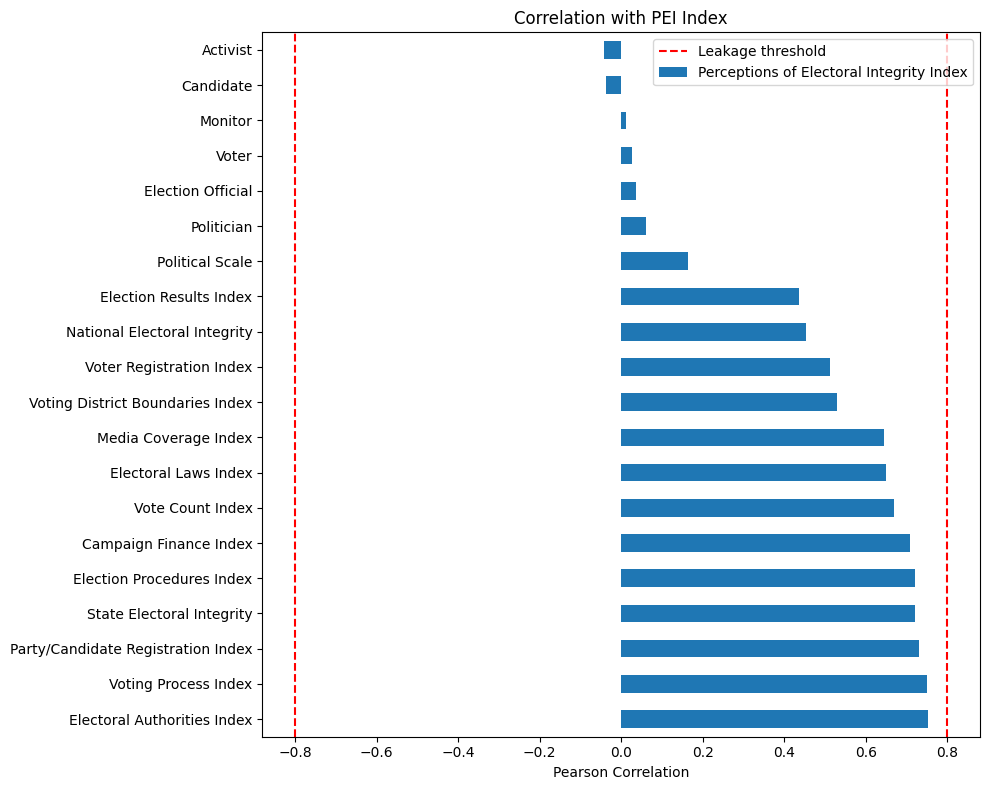

Electoral Authorities Index           0.753217
Voting Process Index                  0.750357
Party/Candidate Registration Index    0.731522
State Electoral Integrity             0.721186
Election Procedures Index             0.719632
Campaign Finance Index                0.708239
Vote Count Index                      0.668364
Electoral Laws Index                  0.650615
Media Coverage Index                  0.643810
Voting District Boundaries Index      0.529790
Voter Registration Index              0.512500
National Electoral Integrity          0.453265
Election Results Index                0.436793
Political Scale                       0.163846
Politician                            0.062065
Election Official                     0.035818
Voter                                 0.027643
Monitor                               0.011778
Candidate                            -0.038124
Activist                             -0.042411
Name: Perceptions of Electoral Integrity Index, dtype: float

In [20]:
# Select all numeric columns except Election Year and Expert ID
numeric_cols = df.select_dtypes(include='number').drop(columns=['Election Year', 'Expert ID'])

# Correlation with PEI
pei_corr = numeric_cols.corr()['Perceptions of Electoral Integrity Index'].drop('Perceptions of Electoral Integrity Index').sort_values(ascending=False)

# Bar chart (easier to read)
fig, ax = plt.subplots(figsize=(10, 8))
pei_corr.plot(kind='barh', ax=ax)
ax.set_title('Correlation with PEI Index')
ax.set_xlabel('Pearson Correlation')
ax.axvline(x=0.8, color='red', linestyle='--', label='Leakage threshold')
ax.axvline(x=-0.8, color='red', linestyle='--')
ax.legend()
plt.tight_layout()
plt.show()

print(pei_corr)


No signal above 0.8 or below -0.8 so unlikely to be any data leakage. Sub indices are strongly correlated with PEI but none are near perfect. 

- Strong (0.65-0.75): Electoral Authorities, Voting Process, Party/Candidate Registration, State Electoral Integrity, Election Procedures and Campaign Finance.

- Moderate (0.43-0.65): Vote Count, Electoral Laws, Media Coverage, Voting District Boundaries, Voter Registration, National Electoral Integrity and Election Results

- Weak (< 0.2): Political Scale and all role columns. Demographics alone barely predict PEI, interesting predictors are within the integrity assessments.

Regression takeaways:

- A model using index columns will perform well without being leaky.

- A demographics only model will be weak. 

- Role columns are useless as predictors.

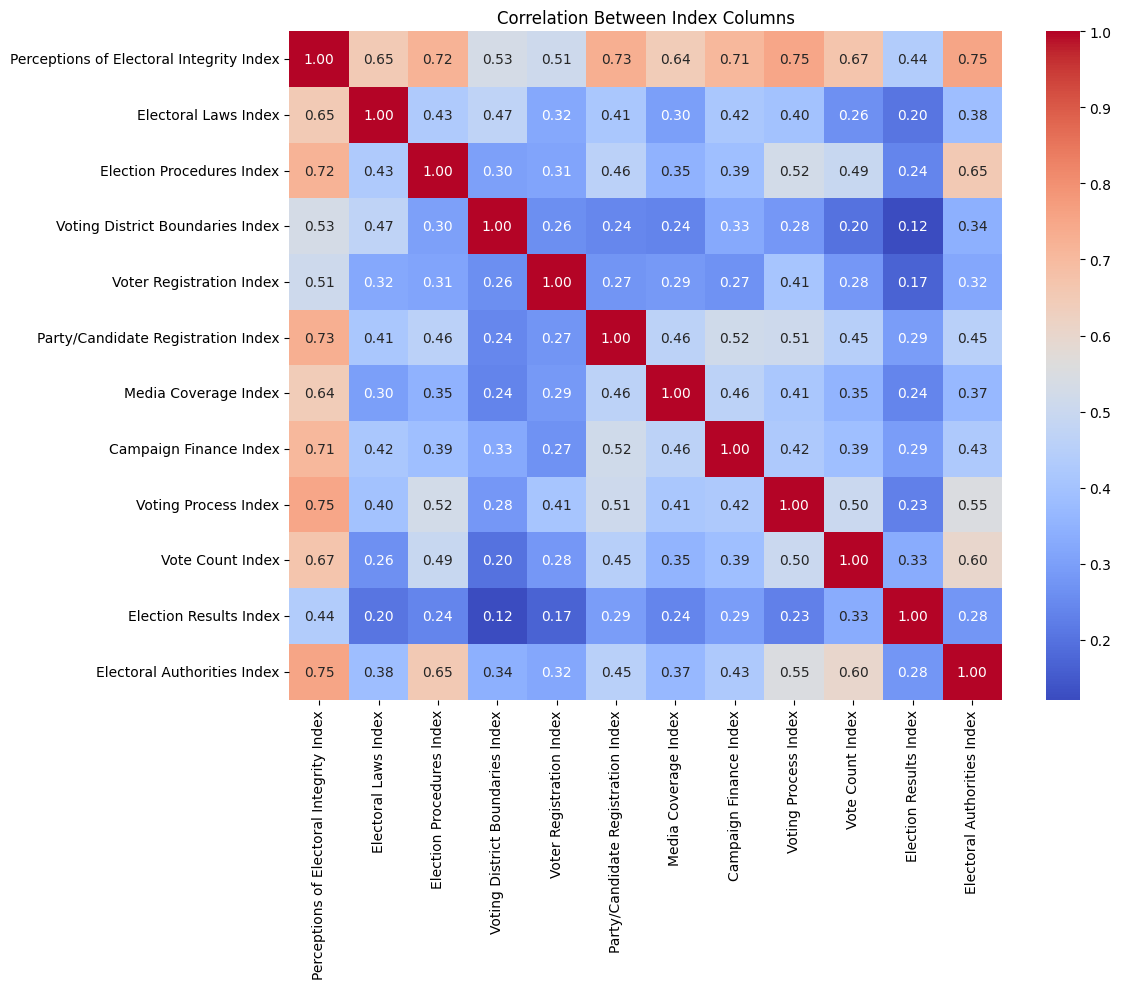

In [21]:
index_cols = [col for col in numeric_cols.columns if 'Index' in col]
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df[index_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=ax)
ax.set_title('Correlation Between Index Columns')
plt.tight_layout()
plt.show()

### 4.3: PEI vs demographic features

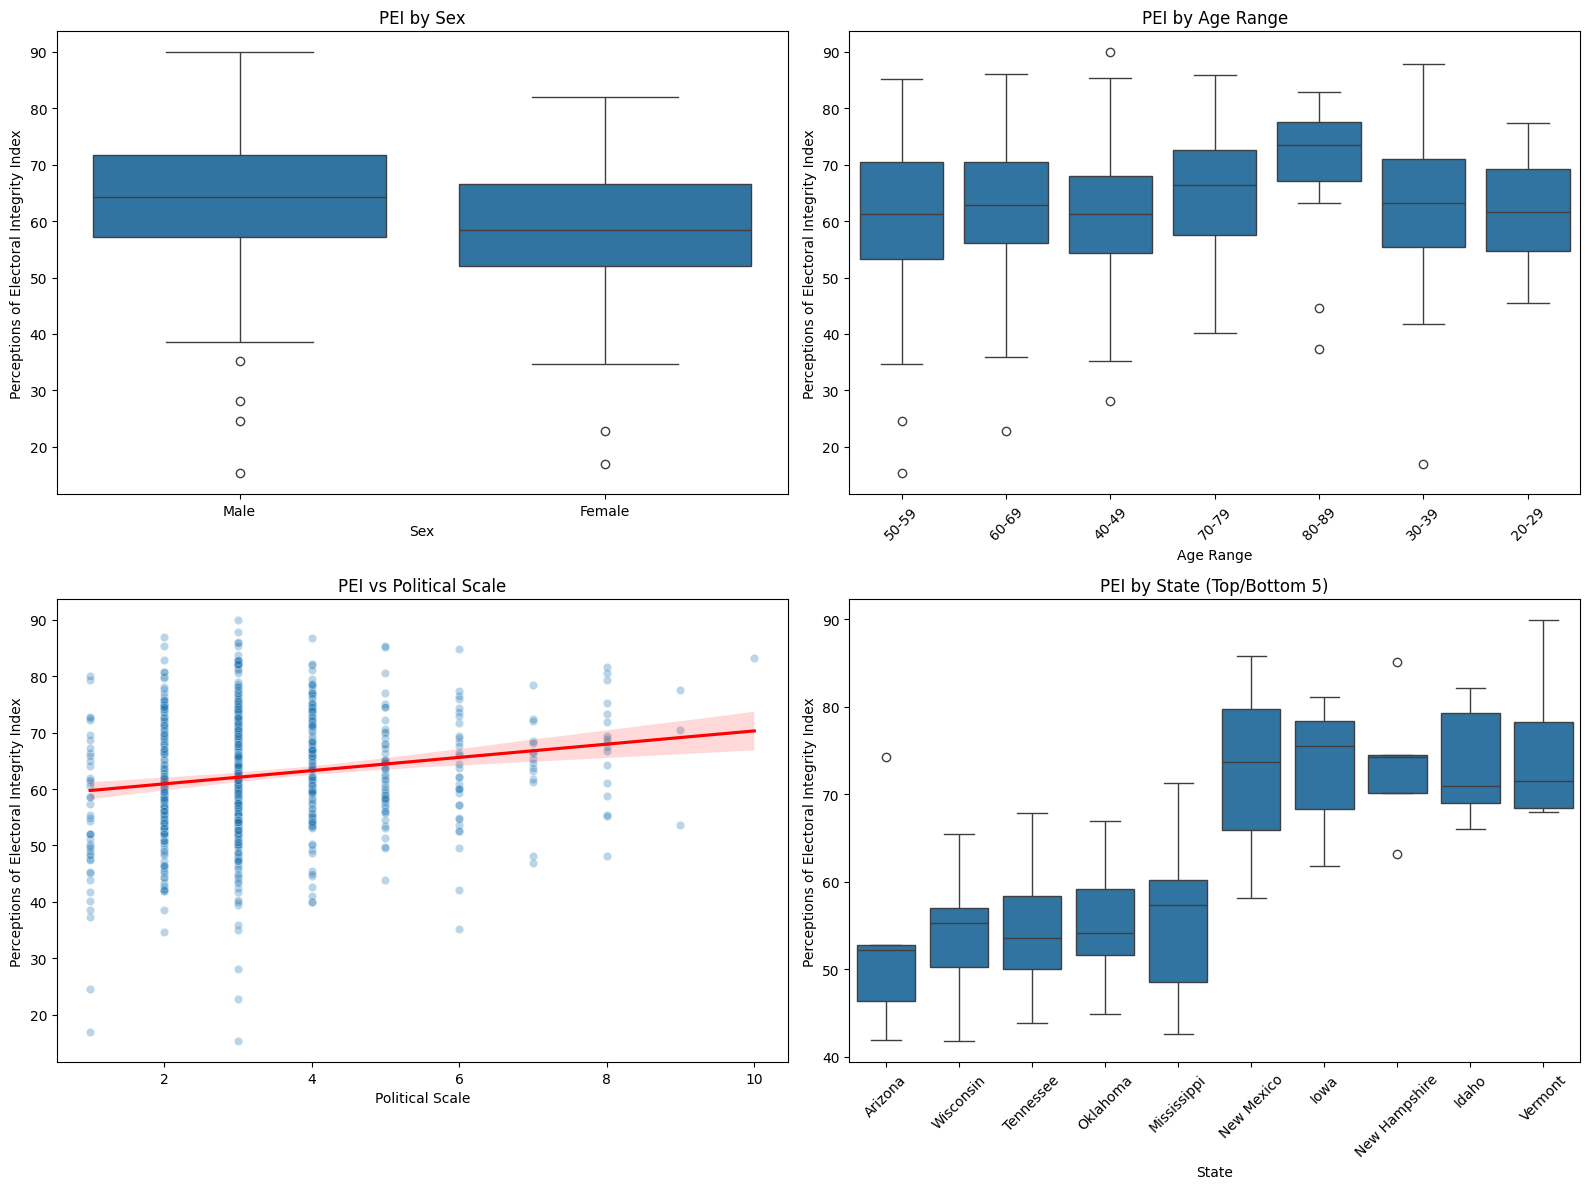

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# PEI by Sex
sns.boxplot(x='Sex', y='Perceptions of Electoral Integrity Index', data=df, ax=axes[0, 0])
axes[0, 0].set_title('PEI by Sex')

# PEI by Age Range
sns.boxplot(x='Age Range', y='Perceptions of Electoral Integrity Index', data=df, ax=axes[0, 1])
axes[0, 1].set_title('PEI by Age Range')
axes[0, 1].tick_params(axis='x', rotation=45)

# PEI vs Political Scale
sns.scatterplot(x='Political Scale', y='Perceptions of Electoral Integrity Index', data=df, alpha=0.3, ax=axes[1, 0])
sns.regplot(x='Political Scale', y='Perceptions of Electoral Integrity Index', data=df, scatter=False, color='red', ax=axes[1, 0])
axes[1, 0].set_title('PEI vs Political Scale')

# PEI by State (top/bottom 5)
state_means = df.groupby('State')['Perceptions of Electoral Integrity Index'].mean().dropna()
top_bottom = pd.concat([state_means.nsmallest(5), state_means.nlargest(5)])
state_df = df[df['State'].isin(top_bottom.index)]
sns.boxplot(x='State', y='Perceptions of Electoral Integrity Index', data=state_df,
            order=top_bottom.sort_values().index, ax=axes[1, 1])
axes[1, 1].set_title('PEI by State (Top/Bottom 5)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

- PEI by Sex: Boxes overalp a lot. Sex doesn't meaningfully predict PEI.

- PEI by Age: 80-89 perceive higher integrity than everybody else (barring two outliers). Bear sample size in mind, they're the smallest group so just representative of a few people not the age range as a whole. However, the same could be said for 20-29 year olds.

- PEI vs Political Scale: shallow upward slope. Conseravtives rate integrity slightly higher. However, points are widely dispersed around the line so Political Scale explains very little variance. Scatter fans out a little but not that much -> proceed with linearity.

- PEI vs State: large gaps between top and bottom states. This suggests that geography matters. IQRs can be relatively wide so experts within the same state disagree. 

In [23]:
df['Age Range'].value_counts()

Age Range
40-49    199
50-59    172
30-39    145
60-69    107
70-79     79
20-29     13
80-89     11
Name: count, dtype: int64

### 4.5: Categorical distributions

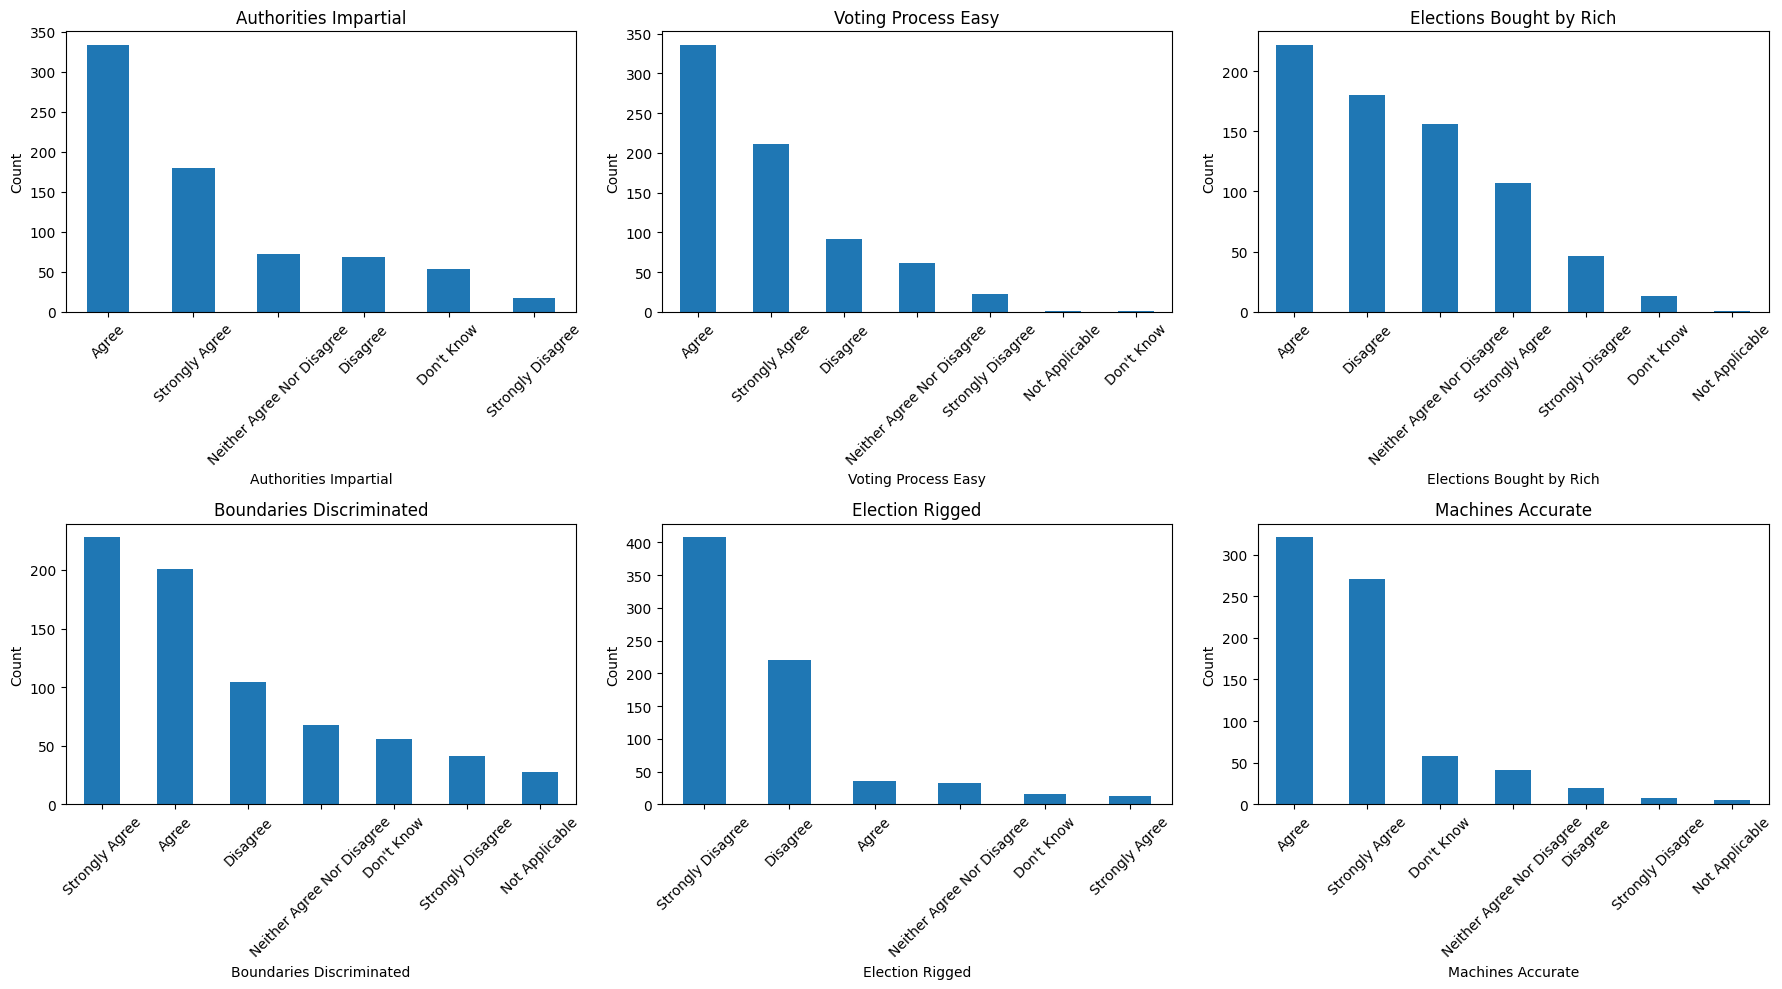

,Don't Know %,Not Applicable %,Total %
International Monitors Restricted,51.652893,15.702479,67.355372
Citizens Not Found in Register,42.699725,0.826446,43.526171
Ineligible Voters Registered,40.771350,0.688705,41.460055
Domestic Monitors Restricted,36.639118,2.892562,39.531680
Dispute Resolved in Courts,28.650138,10.330579,38.980716
Register Inaccurate,38.154270,0.550964,38.705234
Subsidy Access Fair,21.074380,13.774105,34.848485
Resources Improperly Used,29.614325,0.688705,30.303030
Social Media Exposed Fraud,22.589532,5.785124,28.374656
Disabled Provided Access,27.410468,0.137741,27.548209


In [24]:
# Key features (a mix of high and low correlation groups)
key_features = [
    'Authorities Impartial',        
    'Voting Process Easy',          
    'Elections Bought by Rich',     
    'Boundaries Discriminated',     
    'Election Rigged',             
    'Machines Accurate'          
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(key_features):
    ax = axes[i // 3, i % 3]
    counts = df[col].value_counts()
    counts.plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Check Don't Know / Not Applicable proportions across all Likert columns
likert_cols = df.select_dtypes(include=['str', 'object']).columns.drop(['State', 'Sex', 'Age Range', 'Candidate Supported'])
dk_na = pd.DataFrame({
    "Don't Know %": [(df[col] == "Don't Know").sum() / len(df) * 100 for col in likert_cols],
    "Not Applicable %": [(df[col] == "Not Applicable").sum() / len(df) * 100 for col in likert_cols]
}, index=likert_cols)

dk_na['Total %'] = dk_na["Don't Know %"] + dk_na["Not Applicable %"]
dk_na.sort_values('Total %', ascending=False)


Quite a few features where Don't Know or Not Applicable:

- Problematic (>30%): International Monitors Restricted (67%), Citizens Not Found in Register (44%), Ineligible Voters Registered (41%), Domestic Monitors Restricted (40%), Dispute Resolved in Courts (39%), Register Inaccurate (39%), Subsidy Access Fair (35%) and Resources Improperly Used (30%). Experts genuinely don't know about these topics. More noise than signal.

- Moderate (15-30%): Social Media Exposed Fraud, Disabled Provided Access, Fraudulent Votes Cast, Voters Intimidated. Usable but 'Don't Know' needs to be carefully encoded.

- Clean (<15%): Reliable features.

Implications for regression:

- Maybe stick to the index columns for features as this is already handled/the values have already been processed.

### 4.6: Feature Set

Choose sub-indices (11 features) only because:

- No leakage

- Avoids the 'Don't Know' problem

- Avoids multicollinearity between raw items

- Good feature-to-sample ratio (11 features for 726 rows)

- Demographics are weak so can be left out

Things to note:

- Might still want to include State Electoral Integrity and National Electoral Integrity as they're highly correlated with PEI. Worth trying both, with and without.

- Political Scale is weak individually but could add value alongside indices. Might try with and without.

## (5) EDA (Classification Focused)

- Target variable distribution
- Candidate vs index columns
- Candidate vs political scale
- Candidate vs demographics 
- Class balance decision

### 5.1: Target Variable Distribution

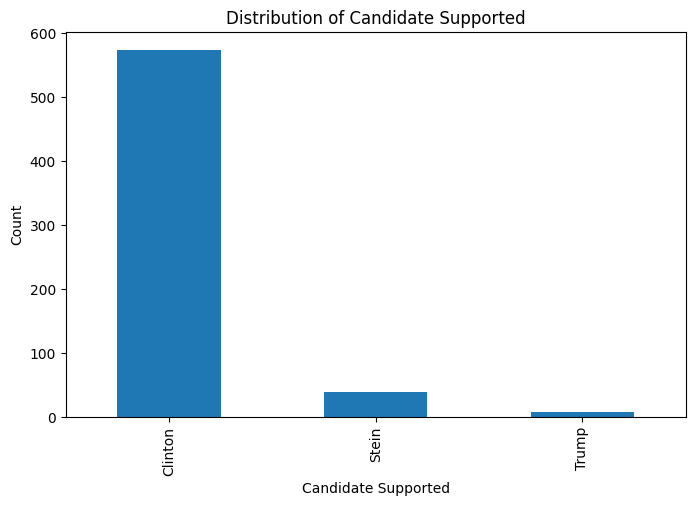

Candidate Supported
Clinton    573
Stein       38
Trump        7
Name: count, dtype: int64

In [25]:
df['Candidate Supported'].value_counts().plot(kind='bar', figsize=(8, 5))
plt.title('Distribution of Candidate Supported')
plt.ylabel('Count')
plt.show()

df['Candidate Supported'].value_counts()

Massively imbalanced, most supported Clinton. Could be a real problem for classification, regular SMOTE could struggle due to sample size.

Not keen on grouping into Clinton vs Other given the sociopolitical ramifications of Trump's two presidencies. Could prove to be a genuine data limitation.

### 5.2: Candidate vs Index Columns

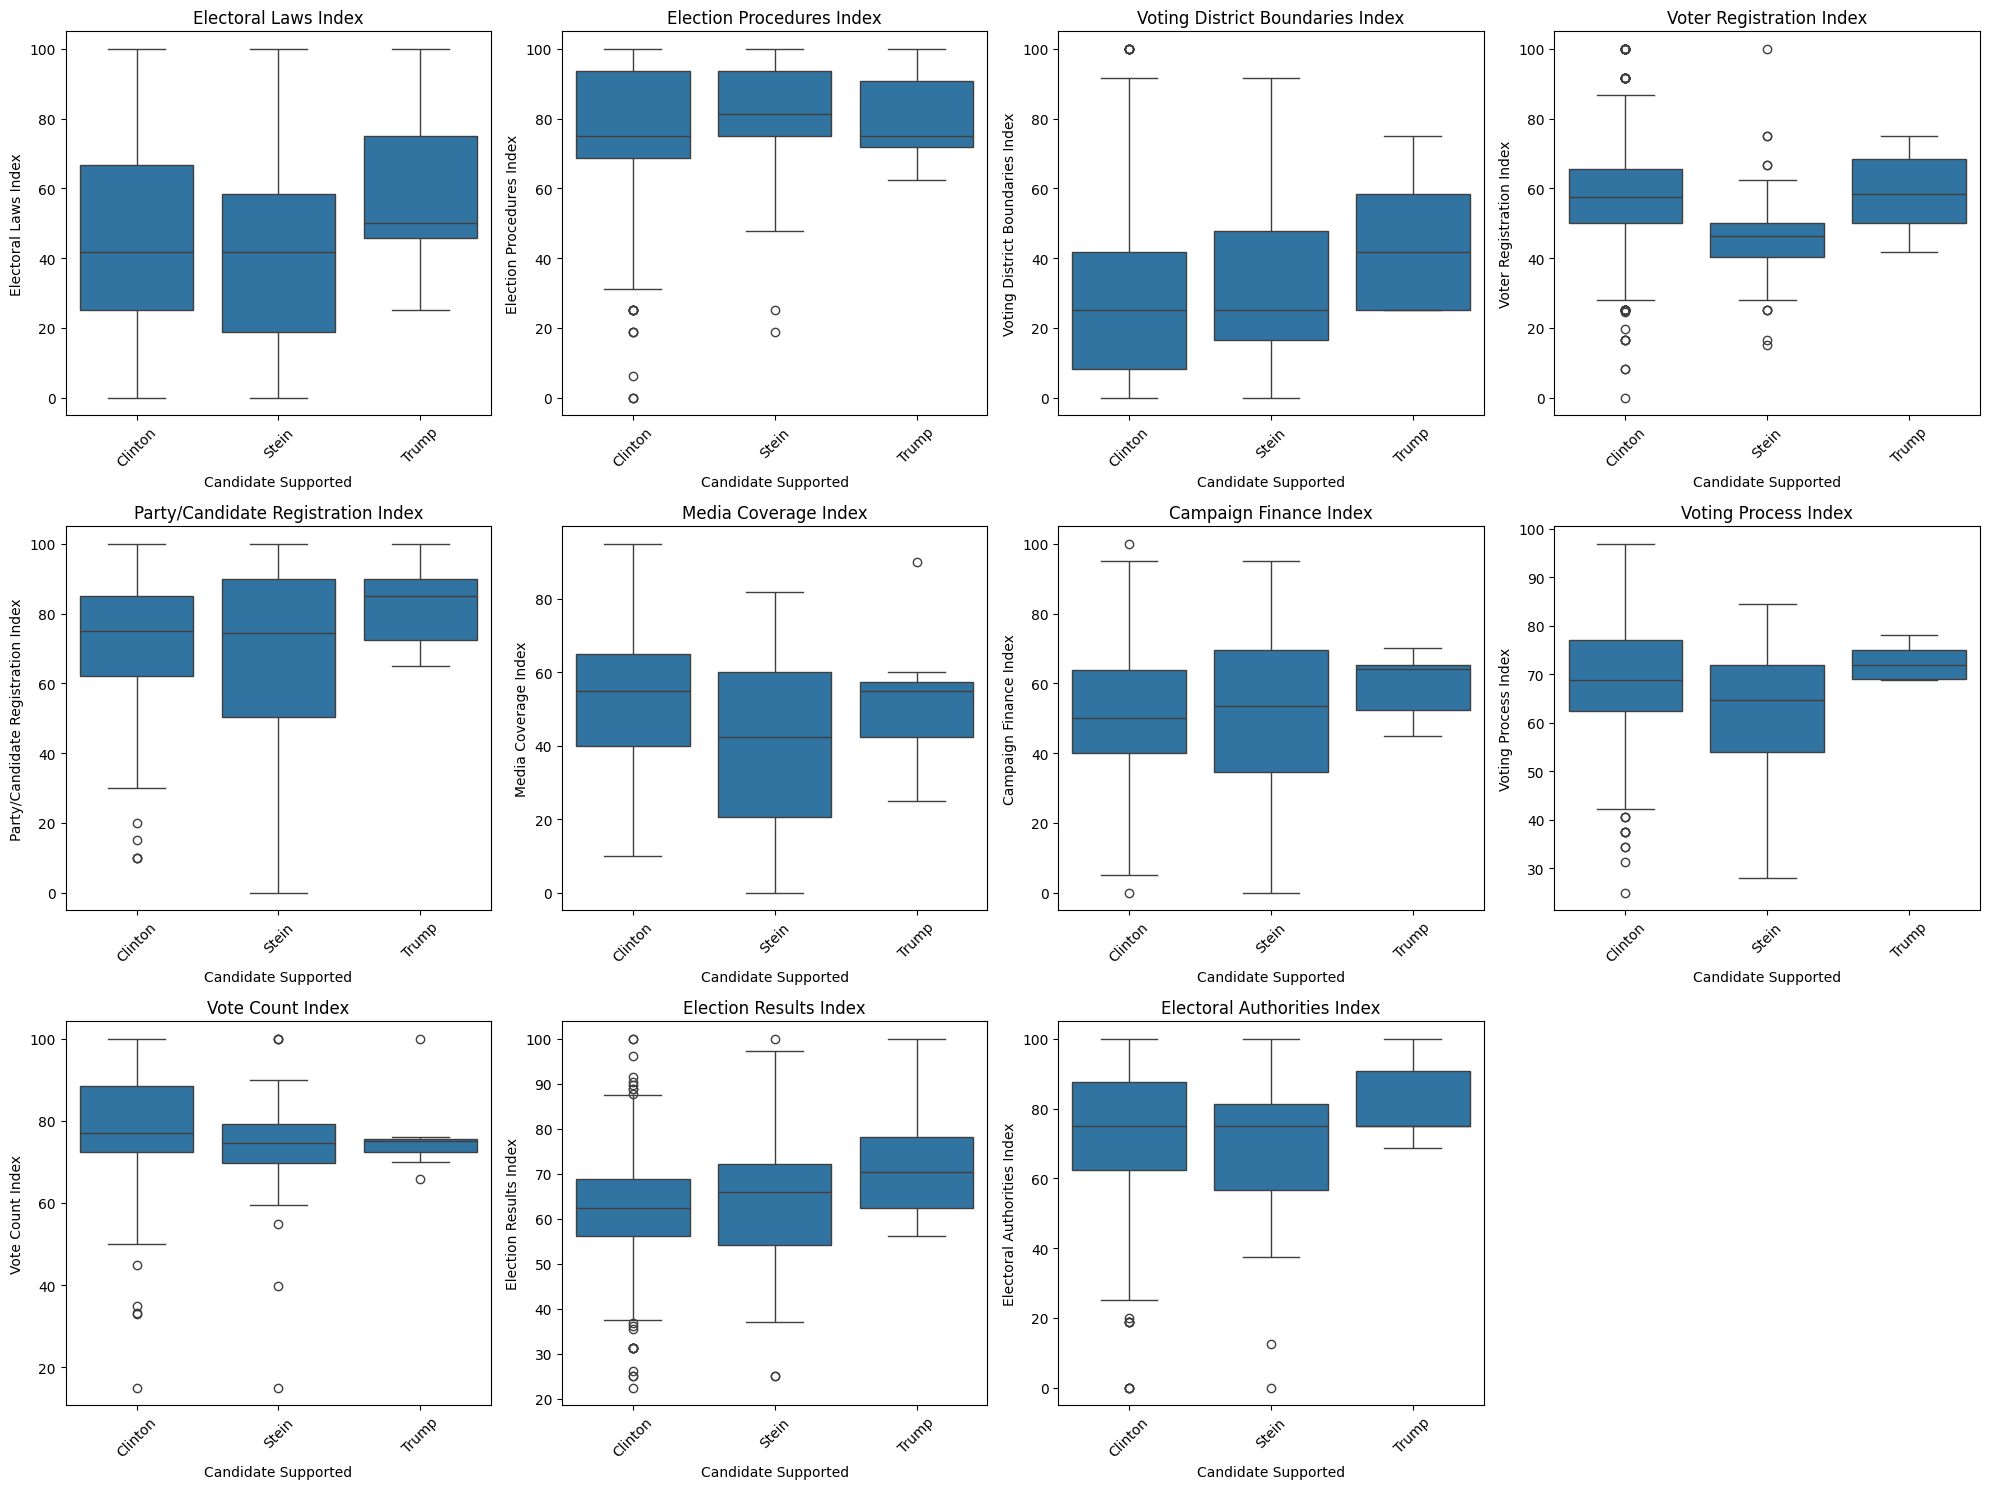

In [26]:
index_cols = [col for col in df.columns if 'Index' in col and 'Perceptions' not in col]

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
for i, col in enumerate(index_cols):
    ax = axes[i // 4, i % 4]
    sns.boxplot(x='Candidate Supported', y=col, data=df, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

# Remove empty subplot if odd number
if len(index_cols) % 4 != 0:
    for j in range(len(index_cols) % 4, 4):
        axes[-1, j].set_visible(False)

plt.tight_layout()
plt.show()

Index boxplots show that Trump supporters rate integrity consistently higher, Stein supporters are more critical but with high variance, and Clinton supporters fall in between.

Electoral Laws, Voting District Boundaries, and Electoral Authorities show the clearest separation between groups. However, Trump's narrow spread reflects only 7 observations rather than genuine consensus. Suggests that three-class classification is not viable with this data.

### 5.3: Candidate vs Political Scale

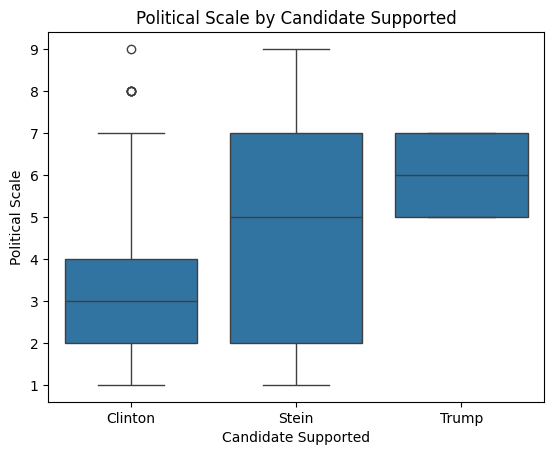

In [27]:
sns.boxplot(x='Candidate Supported', y='Political Scale', data=df)
plt.title('Political Scale by Candidate Supported')
plt.show()

Clinton is the 'furthest' left albeit with a few outliers. Stein has the most spread by far, and Trump is the most right wing.

Surprising amount of spread for Stein, but some are clearly more centrist. Suggetss that Political Scale would seperate Trump clearly, but Clinton and Stein overlap so might not distinguish them well. Stein supporters aren't a coherent group, also seen in the index boxplots above. Trump vs everyone else is the clear separator but there is only 7 samples.

### 5.4: Candidate vs Demographics

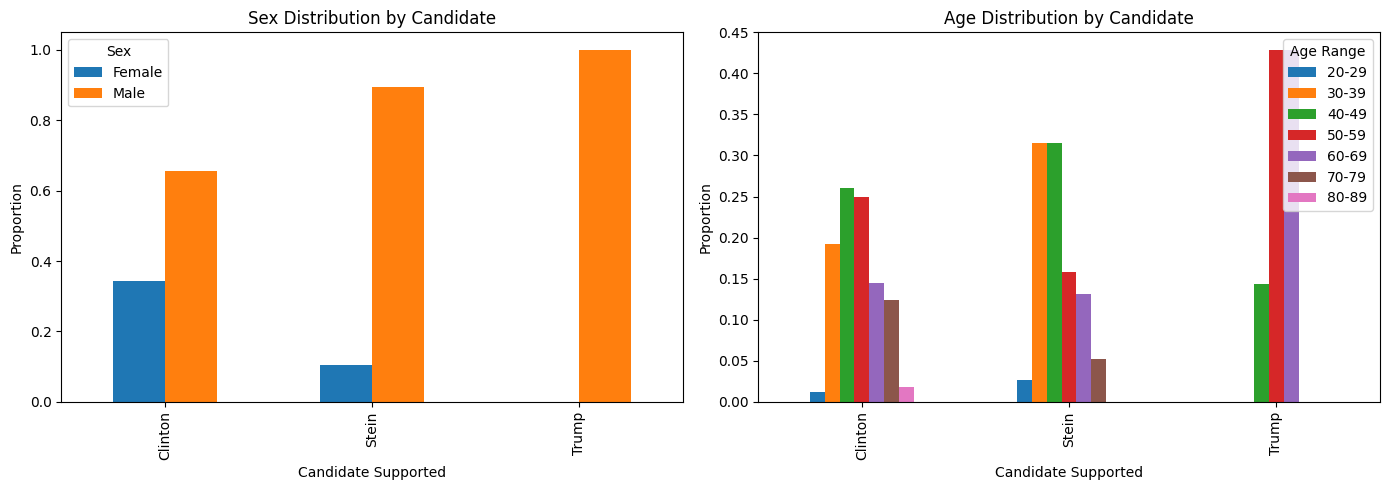

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pd.crosstab(df['Candidate Supported'], df['Sex'], normalize='index').plot(kind='bar', ax=axes[0])
axes[0].set_title('Sex Distribution by Candidate')
axes[0].set_ylabel('Proportion')

pd.crosstab(df['Candidate Supported'], df['Age Range'], normalize='index').plot(kind='bar', ax=axes[1])
axes[1].set_title('Age Distribution by Candidate')
axes[1].set_ylabel('Proportion')

plt.tight_layout()
plt.show()

Clinton's sex distribution is the closest by far. Far smaller proportion of women voted for Stein compared to men. No female Trump voters in the sample. 

Clinton and Stein have wide age distributions, whereas all Trump voters were over 40. However Trump sample size is so small that this is meaningless.

### 5.5: Class Balance Decision

- Might have to do Clinton vs Other and acknowledge why this wasn't preferable.
- Try applying class weights or SMOTE
- Don't focus on accuracy as a metric.

## (6) EDA (Clustering Focused)

- Feature correlation
- Variance across indices
- Distribution of each index
- PCA visualisation

### 6.1: Feature Correlation for Clustering

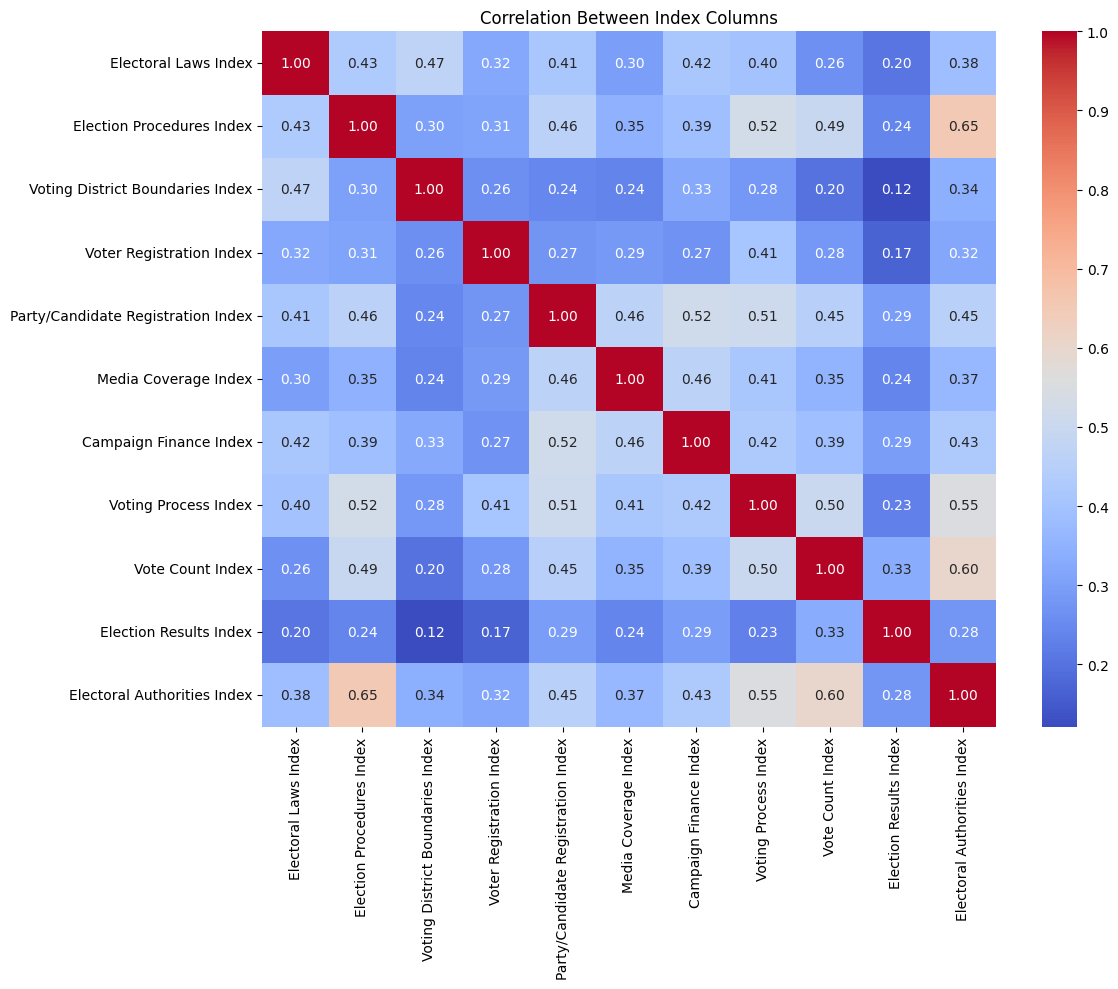

In [29]:
# Clustering will use index columns so check how they correlate with each other
index_cols = [col for col in df.columns if 'Index' in col and 'Perceptions' not in col]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df[index_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=ax)
ax.set_title('Correlation Between Index Columns')
plt.tight_layout()
plt.show()

Only a few correlations over 0.5, and none more than 0.65. Implies that there are no redundant features and that each index captures genuinely different information. Don't need to drop any of the 11 features.

Also implies that PCA may be less critical because features aren't highly correlated

### 6.2: Variance Across Indices

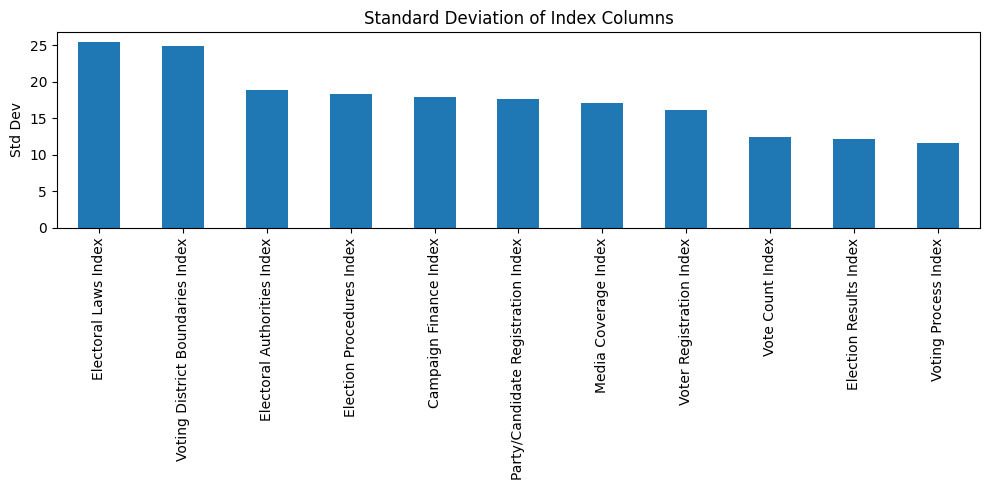

In [30]:
df[index_cols].std().sort_values(ascending=False).plot(kind='bar', figsize=(10, 5))
plt.title('Standard Deviation of Index Columns')
plt.ylabel('Std Dev')
plt.tight_layout()
plt.show()

Some range in variance of indexes that might skew distance based algorithms like K-Means/DBSCAN. Will probably need to scale before clustering.

### 6.3: Distribution of Each Index

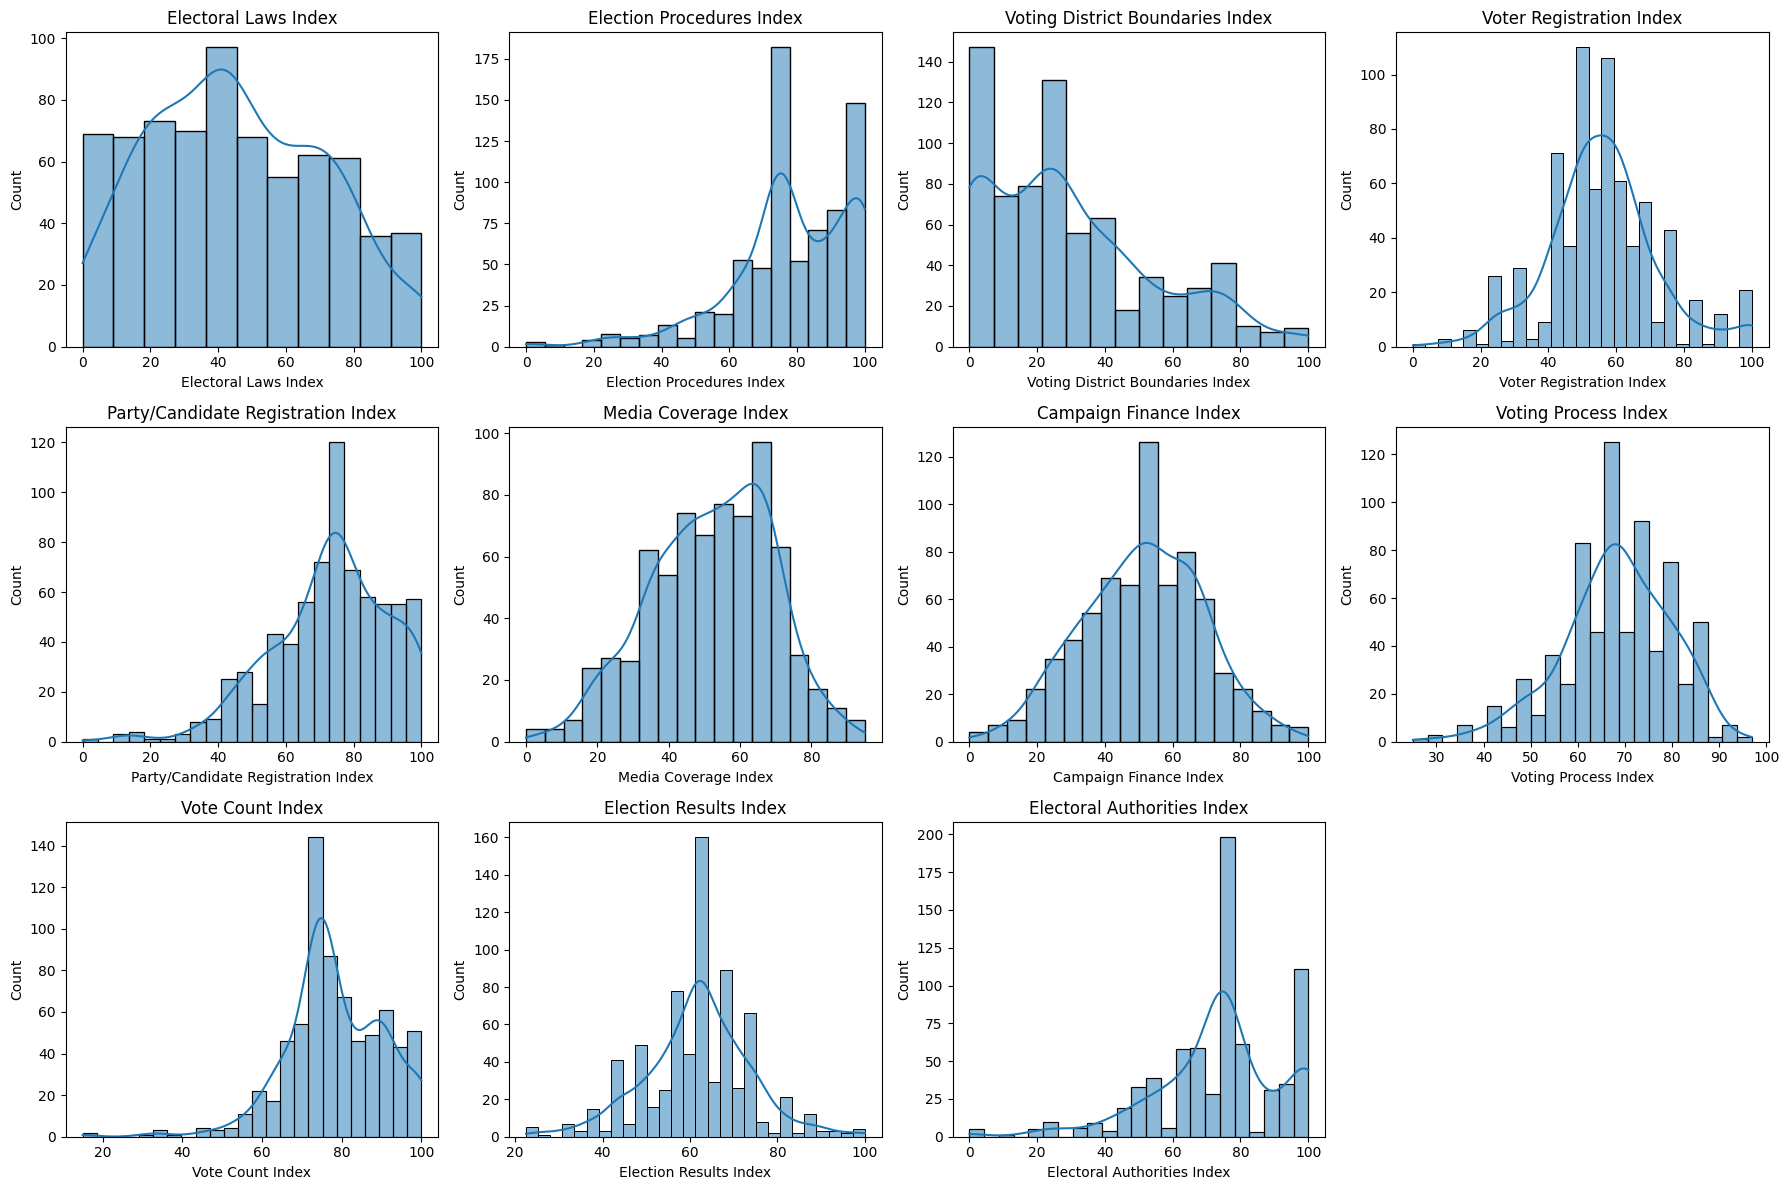

In [31]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for i, col in enumerate(index_cols):
    ax = axes[i // 4, i % 4]
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(col)

for j in range(len(index_cols) % 4, 4):
    axes[-1, j].set_visible(False)

plt.tight_layout()
plt.show()

Quite a few skewed distributions which suggest natural groupings.

### 6.4: PCA Visualisation

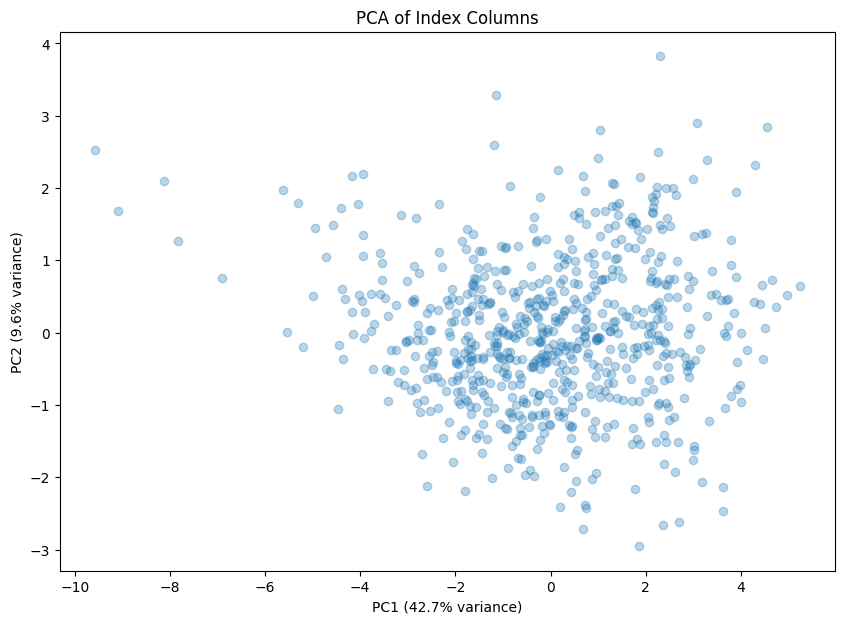

Total variance explained by 2 components: 52.4%


In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

cluster_data = df[index_cols].dropna()
scaled = StandardScaler().fit_transform(cluster_data)

pca = PCA(n_components=2)
components = pca.fit_transform(scaled)

plt.figure(figsize=(10, 7))
plt.scatter(components[:, 0], components[:, 1], alpha=0.3)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA of Index Columns')
plt.show()

print(f'Total variance explained by 2 components: {pca.explained_variance_ratio_.sum():.1%}')

Not a great total variance, and there is a pretty uniform cloud.

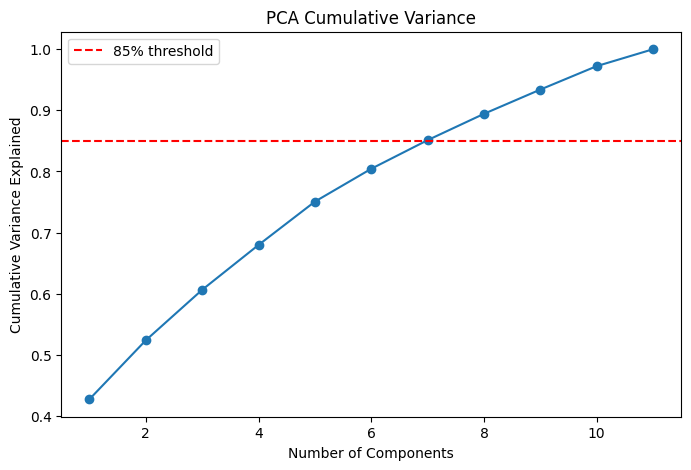

1 components: 42.7%
2 components: 52.4%
3 components: 60.6%
4 components: 68.0%
5 components: 75.1%
6 components: 80.4%
7 components: 85.1%
8 components: 89.4%
9 components: 93.4%
10 components: 97.2%
11 components: 100.0%


In [33]:
# Check how many componnets are needed for 85-90%
pca_full = PCA().fit(scaled)
cumulative = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative) + 1), cumulative, marker='o')
plt.axhline(y=0.85, color='red', linestyle='--', label='85% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('PCA Cumulative Variance')
plt.legend()
plt.show()

for i, var in enumerate(cumulative):
    print(f'{i+1} components: {var:.1%}')

7 components are required to explain 85% of variance. This is genuinely high-dimensional data so can't compress much without losing meaningful information.

- Cluster on all 11 scaled features, not PCA-reduced data.
- PCA only for visualisation
- Curse of dimensionality is mild if indices only are used. K-Means and HDBSCAN can handle 11 dimensions easily.

## Key Takeaways

DATA QUALITY:

- 726 responses and no duplicates. Role columns were binary indicators misread as missing  so imputed with 0. Index columns have minor missingness (<5%) -> median imputation. Candidate Supported has 108 missing and can't impute a target.

REGRESSION:

- Target is approximately normal with slight left skew. Five outliers (PEI 9-29), all left-leaning experts from large/swing states (legitimate, not errors).

- Sub-indices correlate 0.43-0.75 with PEI so strong predictors without leakage (none >0.8).

- Demographics are weak. Political Scale at 0.16 is the only one with any signal. Role columns have near-zero variance and near-zero correlation.

- Feature set: 11 sub-indices. Regularisation justified by moderate multicollinearity and wide-relative-to-deep dataset.

CLASSIFICATION:

- Severely imbalanced. 573 Clinton, 38 Stein, 7 Trump. Three-class classification is not viable with 7 Trump samples.

- Index boxplots show Trump supporters rate integrity higher, Stein supporters are more critical with high variance, Clinton falls between. But, Trump patterns are unreliable at n=7.

- Demographic differences between candidates reflect sample size rather than real effects.

- Task needs reframing (binary classification, Political Scale regression, or honest documentation of failure).

CLUSTERING:

- Index columns are low-correlated (nothing >0.65). Each captures distinct information, no redundancy.

- Variance ranges 13-25 across indices  (StandardScaler required before distance-based algorithms).

- Data is genuinely high-dimensional. 7 of 11 components needed for 85% variance.

- Cluster on all 11 scaled features. PCA for visualisation only, not preprocessing.

OVER-ARCHING:

- Experts rated voting mechanics highly (procedures, vote count) but structural aspects poorly (boundaries, media, finance).

- "Don't Know" rates reach 67% on some raw Likert items so using pre-computed indices avoids this problem.

- The dataset doesn't lend itself to a live prediction system. This is a demonstration of end-to-end ML engineering through an interesting subject.

## Reflection

- This is a survey of political scientists, not a sample of the public. It's not about objective electoral integrity. Left skewing data shows homogeneous sample.

- Survey conducted after 2016 result was known. Responses could be coloured by hindsight.

- Correlation analysis used Pearson, which only captures linear relationships. Non-linear associations could be missed.

- Clustering may detect sub-groups on the left rather than truly distinct profiles.

- Imbalance isn't a data problem but the actual composityion of US political scientists. Reframing or resampling won't really change that. Classification may just not be a good fit.

- Should look into georgraphic feature engineering.